# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
!pip install tensorflow
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step 
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


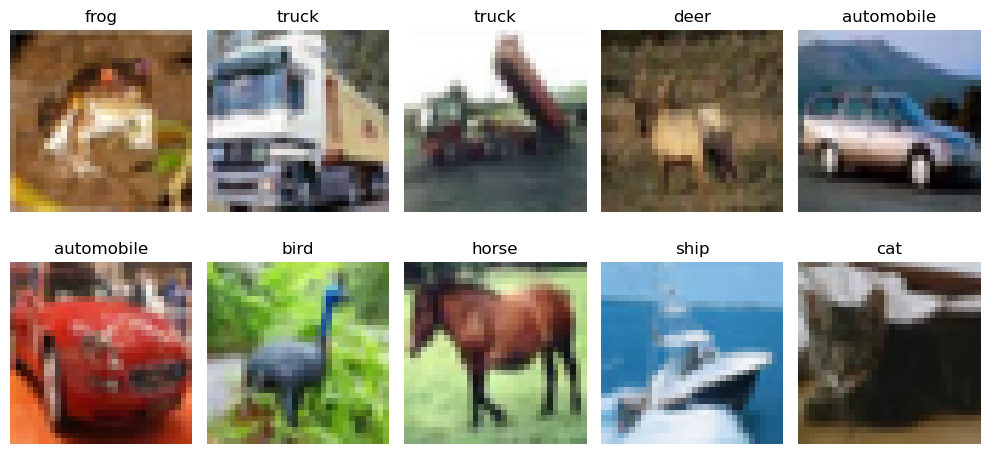

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\Softmgmt\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2718 - loss: 1.9921 - val_accuracy: 0.3170 - val_loss: 1.8780
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3143 - loss: 1.8787 - val_accuracy: 0.3624 - val_loss: 1.7956
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3343 - loss: 1.8248 - val_accuracy: 0.3880 - val_loss: 1.7368
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3480 - loss: 1.7894 - val_accuracy: 0.3790 - val_loss: 1.7475
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3596 - loss: 1.7650 - val_accuracy: 0.3808 - val_loss: 1.7322
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3635 - loss: 1.7527 - val_accuracy: 0.3974 - val_loss: 1.7099
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3697 - loss: 1.7409 - val_accuracy: 0.3972 - val_loss: 1.6895
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.3766 - loss: 1.7174 - va

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4205 - loss: 1.6468 
ANN Test Accuracy: 0.4205000102519989


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\Softmgmt\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.4676 - loss: 1.4930 - val_accuracy: 0.5320 - val_loss: 1.2779
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6165 - loss: 1.1010 - val_accuracy: 0.6372 - val_loss: 1.0301
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6792 - loss: 0.9264 - val_accuracy: 0.6756 - val_loss: 0.9195
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.7210 - loss: 0.8086 - val_accuracy: 0.6406 - val_loss: 1.0855
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7509 - loss: 0.7095 - val_accuracy: 0.7262 - val_loss: 0.8097
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7797 - loss: 0.6346 - val_accuracy: 0.7278 - val_loss: 0.8071
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.7996 - loss: 0.5711 - val_accuracy: 0.7224 - val_loss: 0.8518
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.8199 - loss: 0.5113 - 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6939 - loss: 1.0930
CNN Test Accuracy: 0.6938999891281128


## 📈 Compare Learning Curves

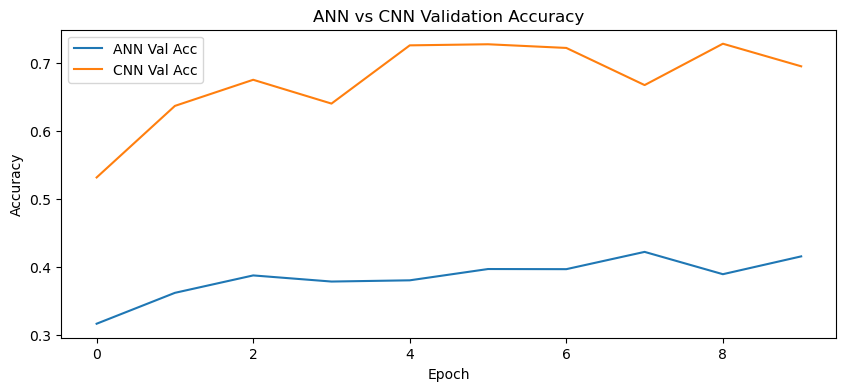

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

## 📈 Interpretation of the Learning Curves

What to look for in the chart above:

- The CNN validation accuracy line sits clearly above the ANN line. This is the main result of the project.
- The ANN flattens early at a lower accuracy. It treats each image as a flat list of 3072 numbers, so it loses all spatial structure (which pixel is next to which).
- The CNN keeps improving because Conv layers look at small patches of the image and learn edges, shapes, and textures. Pooling then keeps the useful signal and reduces size.
- If training accuracy is much higher than validation accuracy, the model is overfitting. Dropout, BatchNormalization, and data augmentation (used later) help close this gap.

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

C:\Users\Softmgmt\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 📊 Final Comparison Table

In [13]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4205
1,CNN,0.6939


## 📚 Key Concepts Used in This Notebook

- **Normalization (0-255 to 0-1):** Smaller, scaled inputs make gradient updates stable and training faster.
- **Dense layer:** A fully connected layer. Every input connects to every neuron. Good for final classification, weak for raw images.
- **Conv2D:** Slides small filters over the image to detect local patterns like edges and corners. This keeps spatial information.
- **BatchNormalization:** Normalizes the outputs of a layer during training. It speeds up training and makes it more stable.
- **MaxPooling2D:** Keeps the strongest value in each small region. It shrinks the feature maps and keeps the important signal.
- **Dropout:** Randomly turns off some neurons during training so the model does not memorize the training data (less overfitting).
- **Data Augmentation:** Creates flipped, rotated, and zoomed versions of images during training so the model sees more variety and generalizes better.
- **EarlyStopping:** Stops training automatically when validation loss stops improving, and restores the best weights. This saves time and avoids overfitting.
- **Why CNN beats ANN on images:** ANN flattens the image and loses the 2D structure. CNN preserves it and learns features in a hierarchy, so it needs fewer parameters and reaches higher accuracy.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## ✅ Task 1: Increase ANN Layers and Observe Performance

We make the ANN deeper by adding one more Dense block (512 -> 256 -> 128) with Dropout.
The goal is to check whether a deeper fully-connected network helps when the input is a flat image vector.

In [14]:
# TASK 1: Deeper ANN
ann_model_v2 = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_v2_history = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_v2_loss, ann_v2_acc = ann_model_v2.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_v2_acc)

C:\Users\Softmgmt\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.2396 - loss: 2.0432 - val_accuracy: 0.3026 - val_loss: 1.9050
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.2947 - loss: 1.9182 - val_accuracy: 0.3366 - val_loss: 1.8446
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3124 - loss: 1.8708 - val_accuracy: 0.3478 - val_loss: 1.8167
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.3270 - loss: 1.8389 - val_accuracy: 0.3712 - val_loss: 1.7663
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3376 - loss: 1.8178 - val_accuracy: 0.3868 - val_loss: 1.7491
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3460 - loss: 1.7936 - val_accuracy: 0.3878 - val_loss: 1.7481
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3542 - loss: 1.7766 - val_accuracy: 0.3952 - val_loss: 1.7366
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.3590 - loss: 1.7685 - val_acc

## ✅ Task 2: Scale CNN Filters 32 → 64 → 128

A deeper CNN with a clear filter progression. Early layers use few filters to learn simple edges.
Deeper layers use more filters to learn complex patterns. `padding='same'` keeps the size controlled,
and a BatchNorm block is added after every Conv layer for stable training.

In [15]:
# TASK 2: Improved CNN with filters 32 -> 64 -> 128
cnn_model_v2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_v2.summary()

C:\Users\Softmgmt\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

## ✅ Task 3 & 4: Train for 20 Epochs with EarlyStopping

We train the improved CNN for up to 20 epochs. EarlyStopping watches the validation loss and stops
training when it stops improving for 3 epochs in a row, then restores the best weights.
This covers both the "20 epochs" task and the "EarlyStopping" task.

In [16]:
# TASK 3 & 4: 20 epochs + EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_v2_history = cnn_model_v2.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_v2_loss, cnn_v2_acc = cnn_model_v2.evaluate(x_test_norm, y_test)
print("Improved CNN (20 epochs + EarlyStopping) Test Accuracy:", cnn_v2_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.4774 - loss: 1.4954 - val_accuracy: 0.5668 - val_loss: 1.1944
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6173 - loss: 1.0890 - val_accuracy: 0.5830 - val_loss: 1.2189
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.6824 - loss: 0.9084 - val_accuracy: 0.7126 - val_loss: 0.8555
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7273 - loss: 0.7833 - val_accuracy: 0.7346 - val_loss: 0.7816
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 42ms/step - accuracy: 0.7592 - loss: 0.6940 - val_accuracy: 0.6992 - val_loss: 0.8959
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7849 - loss: 0.6144 - val_accuracy: 0.7316 - val_loss: 0.7984
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.8069 - loss: 0.5480 - val_accuracy: 0.6948 - val_loss: 0.9265
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7126 - loss: 0.8321
Improved CNN (2

## ✅ Task 5: Train a CNN with Data Augmentation

We reuse the `data_augmentation` pipeline defined earlier (RandomFlip, RandomRotation, RandomZoom)
and place it at the start of the model. Augmentation is active only during training, so each epoch the
model sees slightly different images. This reduces overfitting and improves generalization.

In [17]:
# TASK 5: Augmented training run (reuses data_augmentation from the section above)
aug_cnn_train = models.Sequential([
    layers.Input(shape=(32,32,3)),
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_train.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_train.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_loss, aug_acc = aug_cnn_train.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.4085 - loss: 1.6606 - val_accuracy: 0.5276 - val_loss: 1.3515
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.5075 - loss: 1.3830 - val_accuracy: 0.5554 - val_loss: 1.2745
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.5572 - loss: 1.2570 - val_accuracy: 0.5826 - val_loss: 1.1897
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5077 - loss: 1.3748
Augmented CNN Test Accuracy: 0.5077000260353088


# 📊 Final Comparison: All Model Variants

This table and chart contrast the test accuracy of every model built in this notebook:
the two baselines (ANN, CNN) and the three improved variants from the student tasks.

In [18]:
# Build the final comparison table
final_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline)",
        "Deeper ANN (Task 1)",
        "Improved CNN 32-64-128 (Task 2-4)",
        "Augmented CNN (Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_v2_acc,
        cnn_v2_acc,
        aug_acc
    ]
})

final_comparison = final_comparison.sort_values(
    "Test Accuracy", ascending=False
).reset_index(drop=True)

final_comparison

,Model,Test Accuracy
0,Improved CNN 32-64-128 (Task 2-4),0.7126
1,CNN (baseline),0.6939
2,Augmented CNN (Task 5),0.5077
3,ANN (baseline),0.4205
4,Deeper ANN (Task 1),0.4199


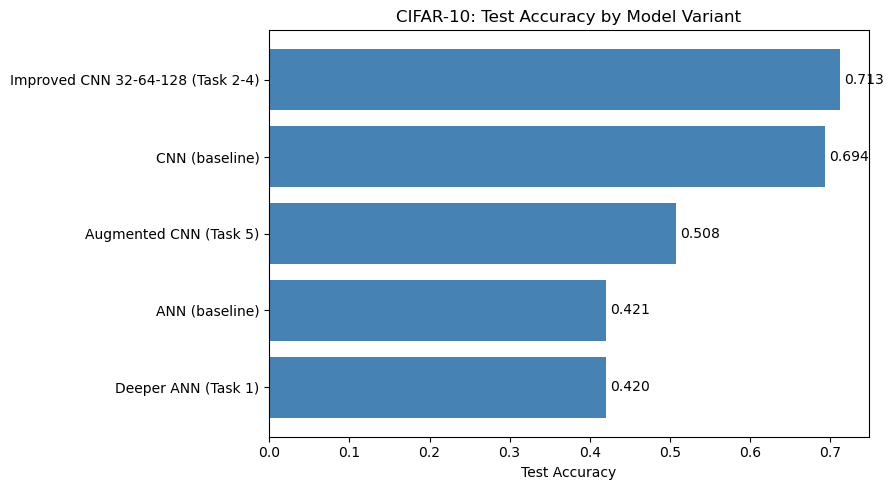

In [19]:
# Bar chart of the final comparison
plt.figure(figsize=(9,5))
plt.barh(final_comparison["Model"], final_comparison["Test Accuracy"], color='steelblue')
plt.xlabel("Test Accuracy")
plt.title("CIFAR-10: Test Accuracy by Model Variant")
plt.gca().invert_yaxis()
for i, v in enumerate(final_comparison["Test Accuracy"]):
    plt.text(v + 0.005, i, f"{v:.3f}", va='center')
plt.tight_layout()
plt.show()